# Week 13/14: ANN
## Project Tasks:
- Implement a simple ANN from scratch in MiniLearn
- Apply one off-the-shelf DL model (e.g., Dense NN, 1D-CNN, or LSTM)
- Compare with classical models
- Finalize report and clean repository

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")

from minilearn import StandardScaler, train_test_split
from minilearn import ANNClassifier
from minilearn import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression as SKLogisticRegression

In [2]:
fpath = os.path.join("../data", "week5_audio.csv")

feature_df = pd.read_csv(fpath)

feature_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,...,spectral_rolloff_std,spectral_rolloff_min,spectral_rolloff_max,path,filename,emotion,intensity,actor,gender,vocal_channel
0,-726.21720,157.85083,-861.53260,-432.15480,68.54142,84.219345,-85.970474,236.70389,3.293398,20.393255,...,7873.634242,0.0000,20929.6875,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutral,normal,1,male,speech
1,-719.12830,159.35600,-861.44400,-417.70416,70.20157,78.612820,-14.972853,218.36372,1.168397,23.063353,...,7634.107567,960.9375,21140.6250,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutral,normal,1,male,speech
2,-714.99570,162.87424,-851.23380,-412.74353,69.68935,85.796005,-45.141598,229.02920,3.924564,17.979307,...,7981.393363,0.0000,21140.6250,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutral,normal,1,male,speech
3,-710.97530,161.77583,-847.86710,-388.34793,67.56488,78.593960,-37.103306,216.24066,5.782241,20.279503,...,7570.671093,937.5000,21187.5000,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutral,normal,1,male,speech
4,-759.92175,162.98659,-917.40265,-454.39650,75.78352,78.566280,-18.632597,230.43222,6.023605,23.161620,...,7902.073642,0.0000,21585.9375,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,calm,normal,1,male,speech


In [3]:
m_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
f_cols = []

for c in feature_df.columns:
    if c not in m_cols:
        f_cols.append(c)

X = feature_df[f_cols]
y = feature_df["emotion"]

In [4]:
# Splits into train, validation, test
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.2,stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.25,stratify=y_train_full)

X_train_full = np.array(X_train_full, dtype=float)
X_test = np.array(X_test, dtype=float)
X_train = np.array(X_train, dtype=float)
X_val = np.array(X_val, dtype=float)
y_train_full = np.array(y_train_full)
y_test = np.array(y_test)
y_train = np.array(y_train)
y_val = np.array(y_val)

scaler1 = StandardScaler()
X_train_scale = scaler1.fit_transform(X_train)
X_val_scale = scaler1.transform(X_val)

scaler2 = StandardScaler()
X_train_full_scale = scaler2.fit_transform(X_train_full)
X_test_scale = scaler2.transform(X_test)

ML ANN validation accuracy:  0.5807770961145194


Text(0, 0.5, 'Cross Entropy Loss')

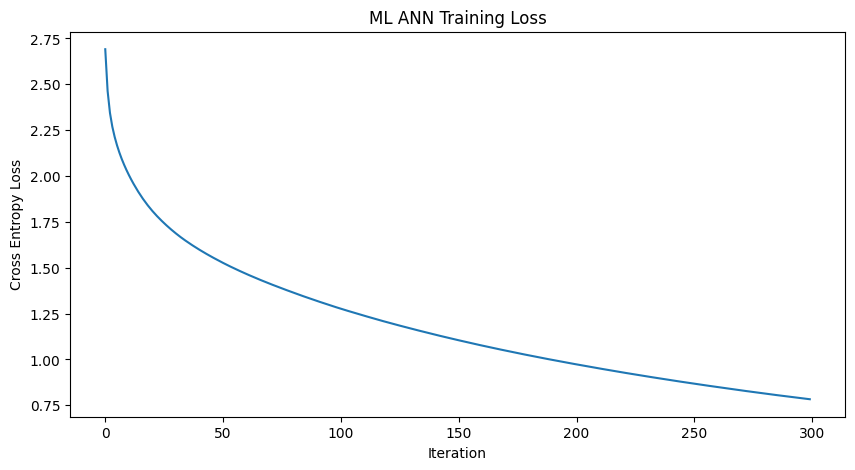

In [5]:
mini_ann = ANNClassifier(hidden_size=24, learning_rate=0.03, n_iter=300, random_state=42)
mini_ann.fit(X_train_scale, y_train)
mini_val_pred = mini_ann.predict(X_val_scale)

print("ML ANN validation accuracy: ", accuracy_score(y_val, mini_val_pred))

plt.figure(figsize=(10,5))
plt.plot(mini_ann.loss_)
plt.title("ML ANN Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Cross Entropy Loss")